#SECTION-A

In [ ]:
# Q-1

# --> NumPy vectorisation is technically superior to a Python for loop because it performs operations on the entire array at once instead of processing each element individually.
# --> For an array containing 50,000 distances, vectorisation is generally faster, more concise, and uses NumPy's optimized internal operations.

# EXAMPLE
import numpy as np
distances=np.array([2,4,6,8])
fees = distances * 5
print(fees)

[10 20 30 40]


In [ ]:
# Q-2

# --> groupby() and agg() are preferable to a for loop because Pandas can group all restaurants and calculate multiple statistics efficiently in one operation.
# --> The loop approach would require repeatedly filtering the DataFrame and manually calculating each average.


In [ ]:
# Q-3

# (a) Total orders per month

# A line chart is appropriate because the data represents monthly values over time. A line chart makes trends, increases, decreases, and seasonal patterns easy to identify.

# (b) Proportion of orders by cuisine

# A pie chart is appropriate because the objective is to show how the total number of orders is divided among four cuisine categories.

# (c) Distribution of delivery times

# A histogram is appropriate because delivery time is numerical data and the objective is to understand its distribution, including concentration, spread, and possible outliers.

Peak Day: 46
Maximum Orders: 496


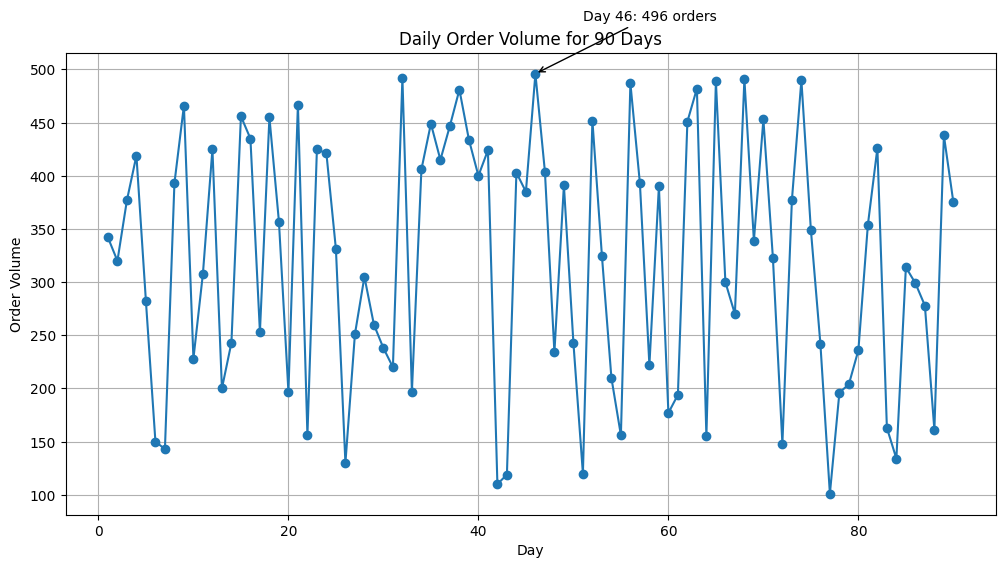

In [1]:
# Q-4

import numpy as np
import matplotlib.pyplot as plt

days = np.arange(1, 91)
order_volume = np.random.randint(100, 500, 90)

max_index = np.argmax(order_volume)
max_day = days[max_index]
max_volume = order_volume[max_index]

print("Peak Day:", max_day)
print("Maximum Orders:", max_volume)

plt.figure(figsize=(12, 6))

plt.plot(days, order_volume, marker='o')

plt.annotate(
    f"Day {max_day}: {max_volume} orders",
    xy=(max_day, max_volume),
    xytext=(max_day + 5, max_volume + 50),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Day")
plt.ylabel("Order Volume")
plt.title("Daily Order Volume for 90 Days")
plt.grid(True)

plt.show()

# np.argmax() identifies the position of the highest order volume. plt.annotate() then marks that peak with an arrow and text.

# Important parameters:

# xy → specifies the exact point where the annotation arrow points.

# xytext → specifies the position where the annotation text is displayed.

# arrowprops → controls the appearance of the arrow.

In [ ]:
# Q-5

# sns.boxplot() vs sns.violinplot()

# For this particular dataset, I would use a boxplot because the manager specifically wants to compare ratings across three categories and identify extreme outliers.

# A boxplot is useful because:

# 1 The dataset contains 10,000 observations, so a boxplot provides a compact summary of a large amount of data.

# 2 There are only three restaurant categories, making category-to-category comparison straightforward.

# 3 Ratings are on a discrete 1–5 scale, so the median, quartiles, and potential extreme observations can be compared clearly.



# --> A violin plot would be preferable when the objective is to understand the shape and density of the distribution,

# --> especially when the variable has many possible continuous values.

# --> A violin plot combines aspects of a boxplot with a density representation.

In [ ]:
# Q-6

# The correlation coefficient ranges from -1 to +1:

# +1 → perfect positive correlation

# 0 → little or no linear correlation

# -1 → perfect negative correlation



#SECTION-B

In [ ]:
# TASK-1

import numpy as np

# Fixed random seed
np.random.seed(42)

# Generate 25 random delivery distances
distances = np.random.uniform(1.0, 15.0, 25)

# Calculate delivery fees using vectorisation
fees = 20 + 5 * distances

# Boolean indexing for fees greater than Rs 60
mask = fees > 60

print("Orders with delivery fee greater than Rs 60:")
print("-" * 50)
print(f"{'Distance (km)':<20}{'Fee (Rs)':<15}")

for distance, fee in zip(distances[mask], fees[mask]):
    print(f"{distance:<20.2f}{fee:<15.2f}")

# Statistics
print("\nFee Statistics:")
print(f"Minimum Fee      : Rs {np.min(fees):.2f}")
print(f"Maximum Fee      : Rs {np.max(fees):.2f}")
print(f"Mean Fee         : Rs {np.mean(fees):.2f}")
print(f"Standard Deviation: Rs {np.std(fees):.2f}")

Orders with delivery fee greater than Rs 60:
--------------------------------------------------
Distance (km)       Fee (Rs)       
14.31               91.55          
11.25               76.24          
9.38                66.91          
13.13               85.63          
9.42                67.08          
10.91               74.57          
14.58               92.89          
12.65               83.27          
8.35                61.73          
9.57                67.83          

Fee Statistics:
Minimum Fee      : Rs 26.44
Maximum Fee      : Rs 92.89
Mean Fee         : Rs 55.86
Standard Deviation: Rs 19.56


In [ ]:
# TASK-2

import numpy as np
import pandas as pd

np.random.seed(42)

# Dataset size
n = 50

restaurants = [
    "Spice Hub",
    "Food Palace",
    "Urban Bites",
    "Tasty Corner",
    "Royal Kitchen"
]

cities = [
    "Mumbai",
    "Ahmedabad",
    "Surat"
]

cuisines = [
    "Indian",
    "Chinese",
    "Fast Food"
]

# Create dataset
df = pd.DataFrame({
    "restaurant_name": np.random.choice(restaurants, n),
    "city": np.random.choice(cities, n),
    "order_value": np.random.uniform(150, 1000, n),
    "delivery_time_mins": np.random.randint(20, 50, n),
    "rating": np.round(np.random.uniform(1.0, 5.0, n), 1),
    "cuisine_type": np.random.choice(cuisines, n)
})

# Group and aggregate
result = (
    df.groupby("restaurant_name")
      .agg(
          mean_order_value=("order_value", "mean"),
          mean_delivery_time=("delivery_time_mins", "mean"),
          mean_rating=("rating", "mean")
      )
      .query("mean_rating > 4.0 and mean_delivery_time < 35")
      .sort_values("mean_order_value", ascending=False)
      .reset_index()
)

# Print complete result
print("Restaurant Performance Report")
print("=" * 70)
print(result.to_string(index=False))

Restaurant Performance Report
Empty DataFrame
Columns: [restaurant_name, mean_order_value, mean_delivery_time, mean_rating]
Index: []


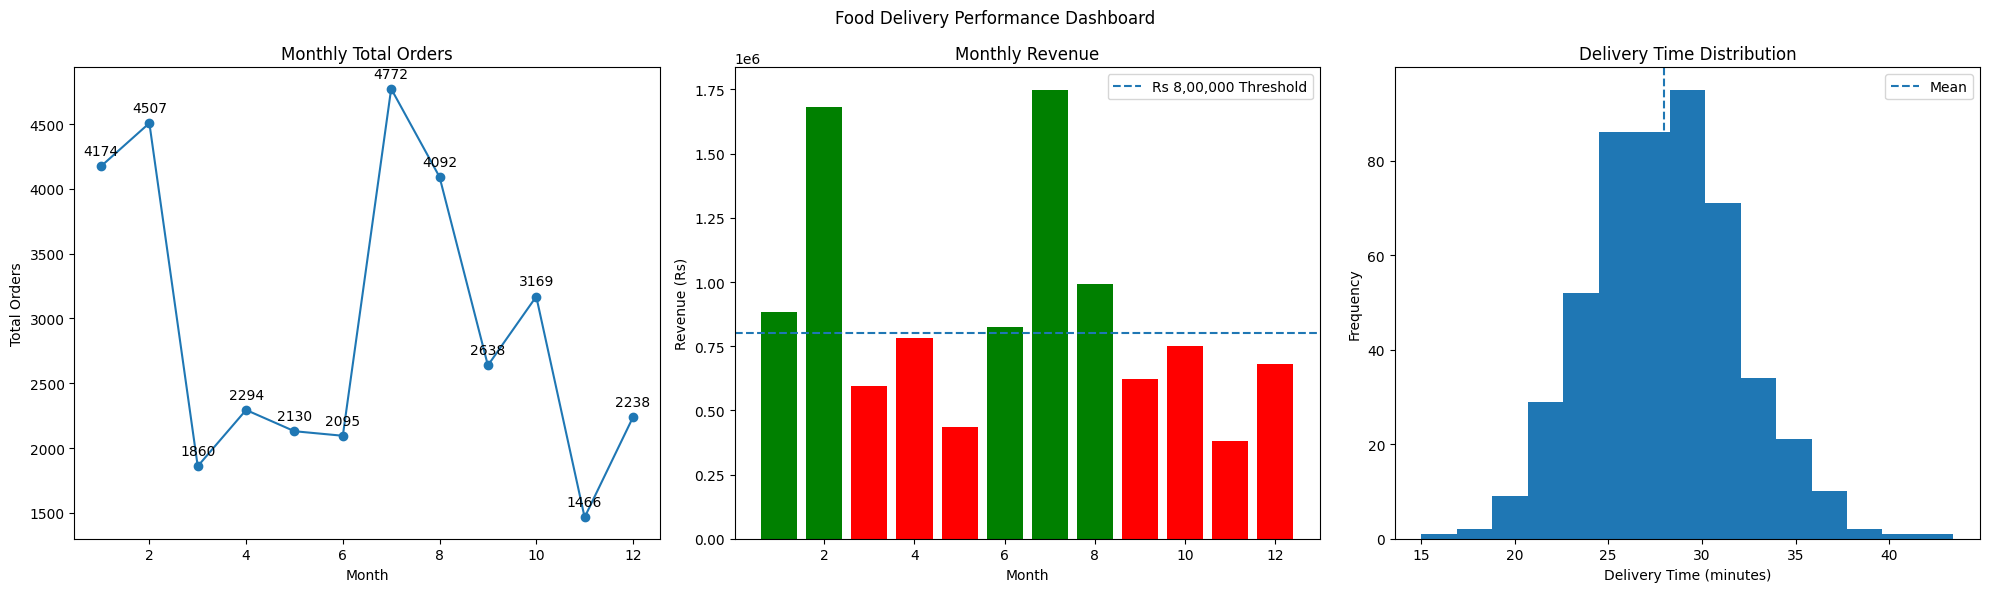

In [ ]:
# TASK-3
import numpy as np
import matplotlib.pyplot as plt

# Fixed seed
np.random.seed(42)

# Months
months = np.arange(1, 13)

# Generate monthly orders
orders = np.random.randint(1000, 5001, 12)

# Generate average order value
avg_order_value = np.random.uniform(200, 400, 12)

# Calculate monthly revenue
revenue = orders * avg_order_value

# Generate delivery times
delivery_times = np.random.normal(28, 4, 500)

# Create figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --------------------------------------------------
# Subplot 1: Line Chart
# --------------------------------------------------

axes[0].plot(
    months,
    orders,
    marker="o"
)

axes[0].set_title("Monthly Total Orders")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Orders")

# Annotate every point
for month, value in zip(months, orders):
    axes[0].annotate(
        str(value),
        (month, value),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

# --------------------------------------------------
# Subplot 2: Revenue Bar Chart
# --------------------------------------------------

bar_colors = [
    "green" if value > 800000 else "red"
    for value in revenue
]

axes[1].bar(
    months,
    revenue,
    color=bar_colors
)

axes[1].axhline(
    800000,
    linestyle="--",
    label="Rs 8,00,000 Threshold"
)

axes[1].set_title("Monthly Revenue")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue (Rs)")
axes[1].legend()

# --------------------------------------------------
# Subplot 3: Histogram
# --------------------------------------------------

axes[2].hist(
    delivery_times,
    bins=15
)

sample_mean = np.mean(delivery_times)

axes[2].axvline(
    sample_mean,
    linestyle="--",
    label="Mean"
)

axes[2].set_title("Delivery Time Distribution")
axes[2].set_xlabel("Delivery Time (minutes)")
axes[2].set_ylabel("Frequency")
axes[2].legend()

# Overall title
fig.suptitle("Food Delivery Performance Dashboard")

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(
    "food_delivery_dashboard.png",
    dpi=150
)

plt.show()

In [ ]:
# TASK-4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1. Generate Dataset
# --------------------------------------------------

np.random.seed(7)

n = 200

df = pd.DataFrame({
    "order_value": np.random.uniform(100, 800, n),
    "distance_km": np.random.uniform(1, 20, n),
    "delivery_time_mins": np.random.normal(30, 8, n),
    "rating": np.random.uniform(1.0, 5.0, n),
    "discount_pct": np.random.uniform(0, 30, n)
})

# --------------------------------------------------
# 2. Introduce 5% Null Values
# --------------------------------------------------

null_count = int(0.05 * n)

delivery_null_indices = np.random.choice(
    df.index,
    size=null_count,
    replace=False
)

rating_null_indices = np.random.choice(
    df.index,
    size=null_count,
    replace=False
)

df.loc[delivery_null_indices, "delivery_time_mins"] = np.nan
df.loc[rating_null_indices, "rating"] = np.nan

print("Null values before filling:")
print(df.isnull().sum())

# --------------------------------------------------
# 3. Fill Nulls with Median
# --------------------------------------------------

df["delivery_time_mins"] = df["delivery_time_mins"].fillna(
    df["delivery_time_mins"].median()
)

df["rating"] = df["rating"].fillna(
    df["rating"].median()
)

print("\nNull values after filling:")
print(df.isnull().sum())

# --------------------------------------------------
# 4. Derived Column
# --------------------------------------------------

df["delivery_speed_kmph"] = (
    df["distance_km"] /
    (df["delivery_time_mins"] / 60)
)

# --------------------------------------------------
# 5. Speed Band using qcut
# --------------------------------------------------

df["speed_band"] = pd.qcut(
    df["delivery_speed_kmph"],
    q=3,
    labels=["Slow", "Normal", "Fast"]
)

print("\nFirst 5 rows:")
print(df.head())

# --------------------------------------------------
# 6. Correlation Heatmap
# --------------------------------------------------

numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Pearson Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=150
)

plt.close()

# --------------------------------------------------
# 7. Pairplot
# --------------------------------------------------

pairplot_columns = [
    "order_value",
    "distance_km",
    "delivery_time_mins",
    "rating",
    "speed_band"
]

pairplot = sns.pairplot(
    df[pairplot_columns],
    hue="speed_band"
)

pairplot.fig.suptitle(
    "Food Delivery Pairplot",
    y=1.02
)

pairplot.fig.savefig(
    "pairplot.png",
    dpi=150
)

plt.close()

print("\nEDA completed successfully.")
print("Saved files:")
print("1. correlation_heatmap.png")
print("2. pairplot.png")

Null values before filling:
order_value            0
distance_km            0
delivery_time_mins    10
rating                10
discount_pct           0
dtype: int64

Null values after filling:
order_value           0
distance_km           0
delivery_time_mins    0
rating                0
discount_pct          0
dtype: int64

First 5 rows:
   order_value  distance_km  delivery_time_mins    rating  discount_pct  \
0   153.415803    15.287118           29.436359  1.610398     17.079069   
1   645.943155     2.171641           41.143419  1.247733      4.256927   
2   406.886462    15.151650           20.002291  3.033249     18.347489   
3   606.425624    18.979243           18.019293  3.033249     29.233717   
4   784.592658    12.467631           24.767687  3.171931      8.202608   

   delivery_speed_kmph speed_band  
0            31.159664       Fast  
1             3.166934       Slow  
2            45.449742       Fast  
3            63.196404       Fast  
4            30.202978     

#SECTION-C

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ==================================================
# DATASET GENERATION
# ==================================================

np.random.seed(42)

n = 250

restaurants = [
    "Spice Hub",
    "Food Palace",
    "Urban Bites",
    "Tasty Corner",
    "Royal Kitchen"
]

cuisines = [
    "Indian",
    "Chinese",
    "Fast Food",
    "Desserts"
]

df = pd.DataFrame({
    "restaurant_name": np.random.choice(restaurants, n),
    "cuisine_type": np.random.choice(cuisines, n),
    "order_value": np.random.uniform(100, 1000, n),
    "distance_km": np.random.uniform(1, 20, n),
    "delivery_time_mins": np.random.normal(30, 7, n),
    "rating": np.random.uniform(1, 5, n),
    "discount_pct": np.random.uniform(0, 30, n)
})


# ==================================================
# NULL VALUE HANDLING
# ==================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:
    if df[column].isnull().any():
        df[column] = df[column].fillna(
            df[column].median()
        )


# ==================================================
# OPTION 1 — SUMMARY STATISTICS
# ==================================================

def summary_statistics():

    print("\n===== SUMMARY STATISTICS =====")

    print("\nMean:")
    print(df[numeric_columns].mean())

    print("\nStandard Deviation:")
    print(df[numeric_columns].std())

    print("\nMinimum:")
    print(df[numeric_columns].min())

    print("\nMaximum:")
    print(df[numeric_columns].max())


# ==================================================
# OPTION 2 — DISTRIBUTION ANALYSIS
# ==================================================

def distribution_analysis():

    print("\n===== DISTRIBUTION ANALYSIS =====")

    print(
        "\nAverage Delivery Time:",
        round(
            np.mean(df["delivery_time_mins"]),
            2
        )
    )

    print(
        "Standard Deviation:",
        round(
            np.std(df["delivery_time_mins"]),
            2
        )
    )

    plt.figure(figsize=(8, 5))

    plt.hist(
        df["delivery_time_mins"],
        bins=15
    )

    plt.title("Delivery Time Distribution")
    plt.xlabel("Delivery Time (minutes)")
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
        "distribution_analysis.png",
        dpi=150
    )

    plt.close()

    print("Chart saved as distribution_analysis.png")


# ==================================================
# OPTION 3 — CORRELATION HEATMAP
# ==================================================

def correlation_heatmap():

    print("\n===== CORRELATION HEATMAP =====")

    correlation = df[numeric_columns].corr()

    plt.figure(figsize=(9, 7))

    sns.heatmap(
        correlation,
        annot=True,
        cmap="coolwarm",
        center=0
    )

    plt.title("Correlation Heatmap")

    plt.tight_layout()

    plt.savefig(
        "correlation_heatmap.png",
        dpi=150
    )

    plt.close()

    print("Chart saved as correlation_heatmap.png")


# ==================================================
# OPTION 4 — RESTAURANT PERFORMANCE
# ==================================================

def restaurant_performance():

    print("\n===== RESTAURANT PERFORMANCE =====")

    performance = (
        df.groupby("restaurant_name")
          .agg(
              mean_order_value=("order_value", "mean"),
              mean_delivery_time=("delivery_time_mins", "mean"),
              mean_rating=("rating", "mean")
          )
          .sort_values(
              "mean_rating",
              ascending=False
          )
    )

    print(performance)

    # Create chart
    plt.figure(figsize=(9, 5))

    plt.bar(
        performance.index,
        performance["mean_rating"]
    )

    plt.title("Average Restaurant Rating")
    plt.xlabel("Restaurant")
    plt.ylabel("Mean Rating")

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.savefig(
        "restaurant_performance.png",
        dpi=150
    )

    plt.close()

    print(
        "Chart saved as restaurant_performance.png"
    )


# ==================================================
# FINAL SUMMARY REPORT
# ==================================================

def final_summary_report():

    print("\n")
    print("=" * 60)
    print("FINAL FOOD DELIVERY ANALYTICS REPORT")
    print("=" * 60)

    # Top 3 restaurants by mean rating
    top_restaurants = (
        df.groupby("restaurant_name")["rating"]
          .mean()
          .sort_values(ascending=False)
          .head(3)
    )

    print("\nTop 3 Restaurants by Mean Rating:")
    print(top_restaurants)

    # Correlation matrix
    correlation = df[numeric_columns].corr()

    # Remove diagonal
    correlation_values = correlation.copy()

    np.fill_diagonal(
        correlation_values.values,
        np.nan
    )

    # Find strongest absolute correlation
    absolute_corr = correlation_values.abs()

    max_location = np.unravel_index(
        np.nanargmax(
            absolute_corr.values
        ),
        absolute_corr.shape
    )

    column_1 = correlation.columns[max_location[0]]
    column_2 = correlation.columns[max_location[1]]

    highest_corr = correlation.iloc[
        max_location[0],
        max_location[1]
    ]

    print("\nNumeric Column Pair with Highest Absolute Pearson Correlation:")
    print(
        f"{column_1} and {column_2}"
    )

    print(
        f"Correlation: {highest_corr:.4f}"
    )

    # Delivery time statistics
    mean_delivery = np.mean(
        df["delivery_time_mins"]
    )

    std_delivery = np.std(
        df["delivery_time_mins"]
    )

    print("\nOverall Delivery Time:")
    print(
        f"Mean: {mean_delivery:.2f} minutes"
    )

    print(
        f"Standard Deviation: {std_delivery:.2f} minutes"
    )

    print("=" * 60)


# ==================================================
# MENU
# ==================================================

while True:

    print("\n")
    print("===== FOOD DELIVERY ANALYTICS CONSOLE =====")
    print("1. Summary Statistics")
    print("2. Distribution Analysis")
    print("3. Correlation Heatmap")
    print("4. Restaurant Performance Report")
    print("5. Exit")

    choice = input(
        "Enter your choice: "
    )

    if choice == "1":

        summary_statistics()

    elif choice == "2":

        distribution_analysis()

    elif choice == "3":

        correlation_heatmap()

    elif choice == "4":

        restaurant_performance()

    elif choice == "5":

        final_summary_report()

        print("\nProgram exited successfully.")

        break

    else:

        print(
            "Invalid choice. Please enter 1-5."
        )



===== FOOD DELIVERY ANALYTICS CONSOLE =====
1. Summary Statistics
2. Distribution Analysis
3. Correlation Heatmap
4. Restaurant Performance Report
5. Exit


#SECTION-D

In [ ]:
# STEP-1

# --> Create a Python 3 program using NumPy, Pandas, Matplotlib, and Seaborn.

# --> The program should generate a synthetic food delivery dataset with at least 5 numeric columns and one categorical column called cuisine_type.

# --> Load the generated data into a Pandas DataFrame.

# --> Create a Seaborn pairplot using all numeric columns and use cuisine_type as the hue. Save the pairplot as a PNG file.

# --> Calculate the Pearson correlation matrix for all numeric columns and display it as a Seaborn heatmap with annotated cell values and a diverging colour palette.

# --> Save the heatmap as a separate PNG file with a descriptive filename at DPI 200.

# --> Use a fixed random seed so that the results are reproducible.


In [ ]:
# STEP-2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fixed seed
np.random.seed(42)

# Number of rows
n = 200

# Generate dataset
df = pd.DataFrame({
    "order_value": np.random.uniform(100, 1000, n),
    "distance_km": np.random.uniform(1, 20, n),
    "delivery_time_mins": np.random.normal(30, 7, n),
    "rating": np.random.uniform(1, 5, n),
    "discount_pct": np.random.uniform(0, 30, n),
    "restaurant_age_years": np.random.uniform(1, 15, n),
    "cuisine_type": np.random.choice(
        ["Indian", "Chinese", "Fast Food", "Desserts"],
        n
    )
})

# Make sure numeric columns contain valid numeric values
numeric_columns = df.select_dtypes(
    include=np.number
).columns

# Fill possible numeric null values
for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

# --------------------------------------------------
# Pairplot
# --------------------------------------------------

pairplot = sns.pairplot(
    df,
    vars=numeric_columns,
    hue="cuisine_type"
)

pairplot.fig.suptitle(
    "Food Delivery Numeric Feature Pairplot",
    y=1.02
)

pairplot.fig.savefig(
    "food_delivery_pairplot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

# --------------------------------------------------
# Correlation Heatmap
# --------------------------------------------------

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Food Delivery Pearson Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    "food_delivery_correlation_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

print("Program completed successfully.")
print("Saved:")
print("1. food_delivery_pairplot.png")
print("2. food_delivery_correlation_heatmap.png")

In [ ]:
# STEP-3

# --> I tested the AI-generated code and checked the chart-saving requirements.

# --> I improved the solution by explicitly selecting numeric columns for the correlation matrix and pairplot, handling possible null values in numeric columns, and setting DPI to 200 when saving both charts.

# --> These changes make the code more robust and ensure that the output satisfies the assessment requirements.
